# 04 - Physical Validation and Model Selection

A model can score well on held out data and still be wrong in a way no metric
catches. Shaking must weaken as you move away from an earthquake. That is not
a preference, it is what attenuation means. Nothing in a loss function says
so, so a model is free to produce a map where intensity rises with distance,
or wanders up and down, as long as it fits the training data.

The original version of this project checked by generating shake maps and
looking at them. That has two problems: it does not scale past a handful of
candidates, and nobody else can repeat it. Here the same judgement is made
numerically.

The two are not rivals, though, and this notebook is honest about why. The
numeric check as first written swept distance out to 400 km. New Zealand is
900 km long. Drawing the maps in `src/maps.py` showed a model that had passed
predicting the strongest shaking on the scale in Northland for a Kaikoura
earthquake, 780 km away, in the part of the map the check never looked at.
The check has been extended and the model is now rejected. The numbers are the
test; the pictures are how you find out the test has a hole in it.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import bench as B
import maps as MP
import models as M
import spatial as S
from clean import apply_weight_scheme, expand_to_weighted_labels
from features import MODEL_FEATURES

pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 60)

## Refitting the shortlist

The sweep in notebook 03 caps training rows for the slower families, because
it is ranking forty-four models. Anything examined here is a model that might
actually be deployed, so it is refitted on the whole training set first.

In [2]:
features = pd.read_csv("../data/processed/features.csv")
labels = apply_weight_scheme(
    expand_to_weighted_labels(features, feature_columns=MODEL_FEATURES + ["mmi_mean"]),
    scheme="sqrt",
)
labels["is_weekend"] = labels["is_weekend"].astype(int)
train, test = M.split_by_event(labels, test_size=0.2, verbose=False)

results = pd.read_csv("../data/processed/bench_results.csv")
shortlist = results[~results["status"].str.startswith("failed")].nsmallest(14, "cell_mae")

fitted = B.fit_shortlist(shortlist["model"], train, MODEL_FEATURES)
print(f"refitted {len(fitted)} candidates on {len(train):,} rows")

refitted 14 candidates on 55,703 rows


## The test

An earthquake is held fixed and distance is swept outwards from 5 km to 900 km,
which is the length of the country and therefore the width of any map the model
would be asked to draw.

Four numbers, because models fail in four different ways.

Rank correlation asks whether the trend is downward at all. The fraction of
decreasing steps asks whether it gets there smoothly or in a blotchy zigzag.
Total drop asks whether it varies enough to be worth putting on a map. Those
three are measured on a profile averaged over eight compass bearings, because
a model given azimuth features may legitimately fall faster in one direction
than another and one bearing should not decide the verdict on that.

The fourth number exists because that same averaging hides the opposite
problem. A model that behaves in twenty-three directions and predicts MMI 8 in
the twenty-fourth still averages to something reasonable. So the far field
check looks at each bearing separately and asks a blunter question: does
anywhere beyond 400 km shake harder than the ground above the hypocentre.

In [3]:
checks = []
for name, candidate in fitted.items():
    summary = S.physical_plausibility(candidate.estimator, MODEL_FEATURES, kind=candidate.kind)
    verdict = S.plausibility_verdict(summary)
    checks.append({
        "model": name,
        "worst_spearman": round(summary["worst_spearman"], 3),
        "fraction_decreasing": round(summary["mean_fraction_decreasing"], 3),
        "total_drop": round(summary["mean_total_drop"], 2),
        "far_field_excess": round(summary["far_field_excess"], 2),
        "passes": verdict["passes"],
        "why_not": "; ".join(verdict["reasons"]),
    })

physical = (pd.DataFrame(checks)
            .merge(shortlist[["model", "cell_mae", "auc_mmi6plus"]], on="model")
            .sort_values("cell_mae")
            .reset_index(drop=True))

physical[["model", "cell_mae", "worst_spearman", "fraction_decreasing",
          "total_drop", "far_field_excess", "passes"]]

,model,cell_mae,worst_spearman,fraction_decreasing,total_drop,far_field_excess,passes
0,Hist Gradient Boosting Regressor,0.3365,-0.899,0.917,0.96,-0.11,False
1,Hist Gradient Boosting,0.3498,-0.827,0.795,1.06,3.96,False
2,Gradient Boosting Regressor,0.3688,-0.980,0.917,1.12,-0.26,True
3,Random Forest Regressor,0.3776,-0.630,0.737,0.51,0.47,False
4,Bagging,0.3788,-0.727,0.673,0.44,0.46,False
5,Gradient Boosting,0.3849,-0.975,0.904,1.58,-0.35,True
6,Hist Gradient Boosting (depth 4),0.3893,-0.450,0.904,-1.61,4.01,False
7,Random Forest,0.3905,-0.876,0.647,0.58,0.45,False
8,Decision Tree (depth 5),0.3937,-0.774,1.000,0.36,-0.36,False
9,Random Forest (depth 10),0.3973,-0.896,0.859,0.51,0.29,False


Two of fourteen pass, and the most accurate model is not among them.

### Why strict monotonicity is the wrong test

Requiring every single step to decrease sounds correct. It is not, and the
table shows why.

In [4]:
physical[physical["model"].str.contains("Decision Tree")][
    ["model", "cell_mae", "worst_spearman", "total_drop", "passes", "why_not"]
]

,model,cell_mae,worst_spearman,total_drop,passes,why_not
8,Decision Tree (depth 5),0.3937,-0.774,0.36,False,"weak or inconsistent decay (worst Spearman -0.774, needs..."
11,Decision Tree Regressor (depth 8),0.4103,-0.783,0.56,False,"weak or inconsistent decay (worst Spearman -0.783, needs..."


The shallow decision trees are the only candidates whose every step decreases,
and they manage it by being nearly flat: 0.36 MMI of variation across the
entire country. A map from one would be almost a single colour, and it would
still be strictly monotonic. Meanwhile the tree ensembles predict piecewise
constant surfaces that wobble by thousandths of a unit between neighbouring
distances while falling cleanly overall, and a strict test throws them out.

So the shape test is on the decay as a whole rather than on every step of it:
a strong downward trend, few reversals, and enough range to be worth mapping.

## The far field, and how the hole in the check was found

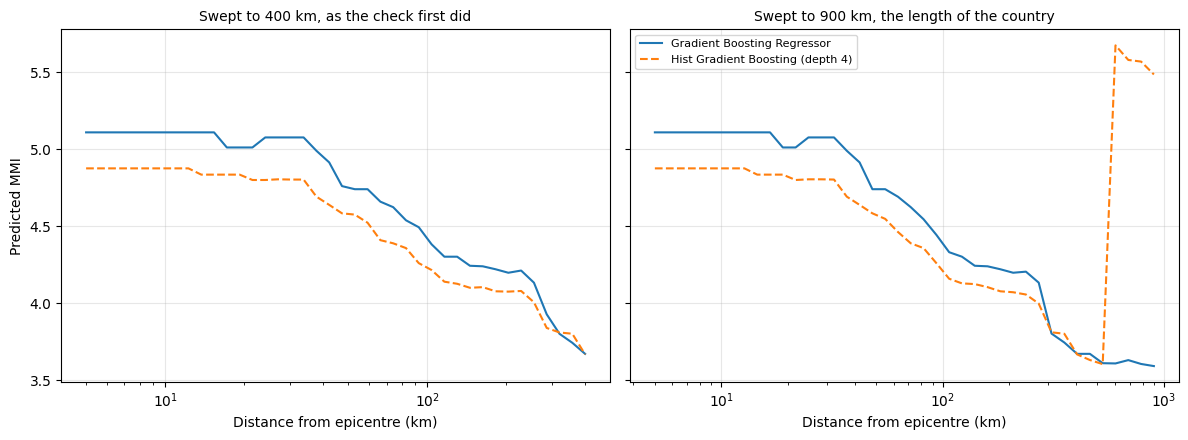

In [5]:
short_sweep = np.geomspace(5, 400, 40)
full_sweep = np.geomspace(5, 900, 40)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, sweep, title in [(axes[0], short_sweep, "Swept to 400 km, as the check first did"),
                         (axes[1], full_sweep, "Swept to 900 km, the length of the country")]:
    for name, style in [("Gradient Boosting Regressor", "-"),
                        ("Hist Gradient Boosting (depth 4)", "--")]:
        candidate = fitted[name]
        profile = S.radial_profile(candidate.estimator, MODEL_FEATURES, magnitude=7.5,
                                   distances_km=sweep, kind=candidate.kind)
        ax.plot(profile["epicentral_distance_km"], profile["predicted_mmi"], style, label=name)
    ax.set_xscale("log")
    ax.set_xlabel("Distance from epicentre (km)")
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Predicted MMI")
axes[1].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

Both models look sound on the left. On the right one of them turns upward past
400 km and climbs to the top of the intensity scale.

That model, Hist Gradient Boosting at depth 4, previously passed with a rank
correlation of -0.987. It was cited in an earlier version of this notebook as
evidence that constraining tree depth improves physical behaviour. It does not.
The constrained model was scoring well on the part of the range that was being
looked at.

In [6]:
for name in ["Gradient Boosting Regressor", "Hist Gradient Boosting (depth 4)"]:
    candidate = fitted[name]
    result = S.far_field_check(candidate.estimator, MODEL_FEATURES,
                               magnitude=7.5, kind=candidate.kind)
    print(f"{name}")
    print(f"  mean MMI within {S.NEAR_FIELD_KM:.0f} km   {result['near_field']:.2f}")
    print(f"  worst MMI beyond {S.FAR_FIELD_KM:.0f} km  {result['max_far_field']:.2f}"
          f"  (bearing {result['worst_bearing']:.0f} degrees)")
    print(f"  excess                  {result['far_field_excess']:+.2f}"
          f"  (allowed {S.MAXIMUM_FAR_FIELD_EXCESS})\n")

Gradient Boosting Regressor
  mean MMI within 50 km   5.05
  worst MMI beyond 400 km  3.81  (bearing 30 degrees)
  excess                  -1.24  (allowed 1.0)

Hist Gradient Boosting (depth 4)
  mean MMI within 50 km   4.82
  worst MMI beyond 400 km  8.00  (bearing 0 degrees)
  excess                  +3.18  (allowed 1.0)



The allowance is one full intensity level rather than zero. Small positive
excesses do occur in the honest models, but only at magnitude 4.5, where
nothing is felt at 400 km in the first place and the prediction is sitting on
its floor, and they vanish at every larger magnitude. MMI is also reported as
whole numbers, so a difference under one unit is finer than the scale itself
resolves.

The separation is not close. Genuine far field blow-ups measure 3 to 4 units
of excess at every magnitude tested; the artefacts measure under 0.6 at one.

## Shake maps

The same judgement as a person would actually read it. `src/maps.py` draws
these for every candidate; two are shown here.

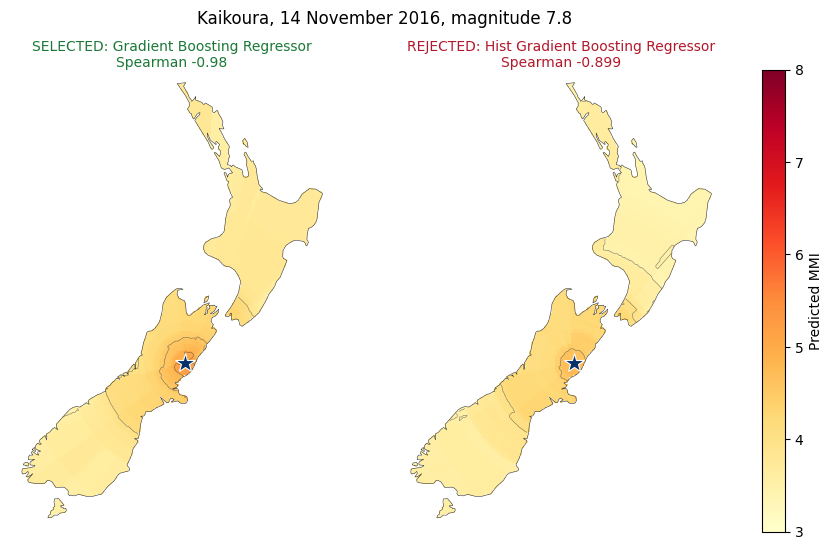

In [7]:
rings = MP.load_coastline()
grid = S.nz_grid(spacing_km=6)

best_overall = physical.iloc[0]
best_passing = physical[physical["passes"]].iloc[0]

fields = {row["model"]: MP.predict_field(fitted[row["model"]], MP.KAIKOURA, grid, rings)
          for _, row in physical.iterrows()}

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
for ax, row, label in [(axes[0], best_passing, "SELECTED"),
                       (axes[1], best_overall, "REJECTED")]:
    mesh = MP.draw(ax, fields[row["model"]], MP.KAIKOURA, rings)
    ax.set_title(f"{label}: {row['model']}\nSpearman {row['worst_spearman']}",
                 fontsize=10,
                 color=MP.PASS_COLOUR if row["passes"] else MP.FAIL_COLOUR)
fig.colorbar(mesh, ax=axes.tolist(), label="Predicted MMI", fraction=0.03)
fig.suptitle(f"{MP.KAIKOURA['name']}, magnitude {MP.KAIKOURA['magnitude']}")
plt.show()

The blue star marks the epicentre. The selected model puts its strongest
shaking there and fades outwards. The rejected one spreads intensity across
the whole South Island with only a weak peak at the source, which is what a
Spearman of -0.899 looks like on a map.

The full contact sheet of all fourteen is in `maps/contact-sheet.png`. It is
worth looking at: most of the panels stay pale even at the epicentre of a
magnitude 7.8 earthquake, because most of these models never predict strong
shaking anywhere. That is the same finding as the MMI 7 recall of zero in
notebook 03, seen from a different angle.

## Selection

The rule is: satisfy the physics first, then take the most accurate model that
does. Accuracy alone would select a model whose maps cannot be trusted.

In [8]:
selected = physical[physical["passes"]].nsmallest(1, "cell_mae").iloc[0]

print("SELECTED")
print(f"  {selected['model']}")
print(f"  cell MAE          {selected['cell_mae']:.4f}")
print(f"  worst Spearman    {selected['worst_spearman']}")
print(f"  total drop        {selected['total_drop']} MMI")
print(f"  far field excess  {selected['far_field_excess']:+.2f}")
print()
print("REJECTED DESPITE BETTER ACCURACY")
print(f"  {best_overall['model']}")
print(f"  cell MAE          {best_overall['cell_mae']:.4f}")
print(f"  worst Spearman    {best_overall['worst_spearman']}  (needs {S.MINIMUM_SPEARMAN})")
print()
cost = selected["cell_mae"] - best_overall["cell_mae"]
print(f"Accuracy given up to get trustworthy maps: {cost:.4f} MAE "
      f"({100 * cost / best_overall['cell_mae']:.1f}%)")

SELECTED
  Gradient Boosting Regressor
  cell MAE          0.3688
  worst Spearman    -0.98
  total drop        1.12 MMI
  far field excess  -0.26

REJECTED DESPITE BETTER ACCURACY
  Hist Gradient Boosting Regressor
  cell MAE          0.3365
  worst Spearman    -0.899  (needs -0.95)

Accuracy given up to get trustworthy maps: 0.0323 MAE (9.6%)


## Summary

- Only two of the fourteen most accurate models produce physically possible
  attenuation across the whole country.
- The most accurate model of all is rejected. Its predictions do not fall
  reliably with distance, so its maps would mislead.
- Selecting on physics first costs about 10% of accuracy and buys a model
  whose output can be acted on.
- Two models predict the top of the intensity scale hundreds of kilometres
  from the earthquake. Both are Hist Gradient Boosting classifiers, and one of
  them was passing until the check was extended to the full length of the
  country.

Metrics alone would have chosen differently, and worse. That is the finding
this project exists to make. Unlike the original version of it the judgement
is reproducible rather than made by eye, but the maps still earned their
place: they are what caught the check looking at only the near half of every
model it was judging.

In [9]:
physical.to_csv("../data/processed/physical_checks.csv", index=False)
print("saved data/processed/physical_checks.csv")

saved data/processed/physical_checks.csv
